# ***Simple Linear Regression Using sklearn & Mini Batch Gradient Descent***

---



In [1]:
#import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [2]:
#Load dataset
data=pd.read_csv('placement.csv')
print(data.head())

   CGPA  Package_LPA
0   5.1          3.2
1   5.3          3.4
2   5.4          3.5
3   5.5          3.6
4   5.6          3.7


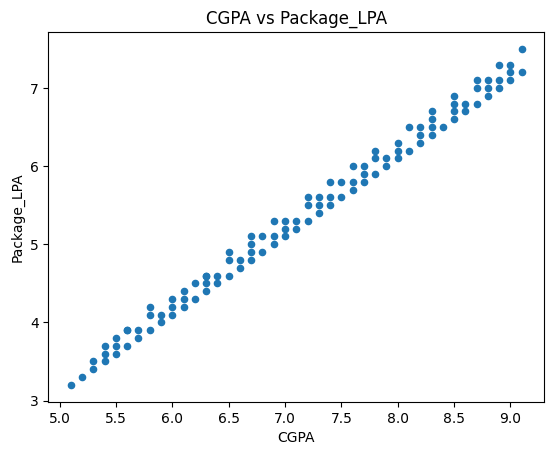

In [3]:
#Check linear or not
data.plot(kind='scatter', x='CGPA', y='Package_LPA')
plt.xlabel('CGPA')
plt.ylabel('Package_LPA')
plt.title('CGPA vs Package_LPA')
plt.show()

In [4]:
#Seprate input and target variable
X=data[['CGPA']] #LinearRegression() expect input vaibles as 2D else give error
y=data['Package_LPA'] #Traget variable as 1D

In [5]:
#Split data into train,test
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42) #random_state ensure the reprodicibility of data

In [6]:
#Fit/Train model on train data
model = SGDRegressor(
    max_iter=1,
    learning_rate='constant',
    eta0=0.01,
    penalty=None
)

#Mini-batch training
batch_size = 2

for epoch in range(100):

    for i in range(0, len(X), batch_size):

        X_batch = X[i:i+batch_size]
        y_batch = y[i:i+batch_size]

        model.partial_fit(X_batch, y_batch)#object creation
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


SGDRegressor(learning_rate='constant', max_iter=1, penalty=None)

In [7]:
#Intercept and Slope
print("Intercept:",model.intercept_)
print("Slope:",model.coef_)

Intercept: [0.05013816]
Slope: [0.73615544]


In [8]:
#Predict for test data
y_pred=model.predict(X_test)
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(comparison.head())

    Actual  Predicted
77     5.3   5.203226
10     4.3   4.614302
4      3.7   4.172609
83     6.3   5.939382
62     6.7   6.307459


In [9]:
#Evalution using Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
n = X_test.shape[0] #Number of rows
p = X_test.shape[1] #Number of columns/Features
adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("Adjusted_R2:", adjusted_r2)

MSE: 0.11434773334788952
RMSE: 0.3381534168803999
MAE: 0.296257714255074
R2: 0.9146250629535233
Adjusted_R2: 0.9103563161011995
